
Consecutive stability (NIGHT):
   b1  b2  spearman_rho       mad
0  10  15      0.416476  0.078727
1  15  20      0.827493  0.031778
2  20  25      0.912784  0.017241
3  25  40      0.704169  0.149927
4  40  50      0.822614  0.114315

Consecutive stability (DAY):
   b1  b2  spearman_rho       mad
0  10  15      0.417628  0.068128
1  15  20      0.824107  0.028485
2  20  25      0.910429  0.016195
3  25  40      0.696246  0.138191
4  40  50      0.818393  0.109547


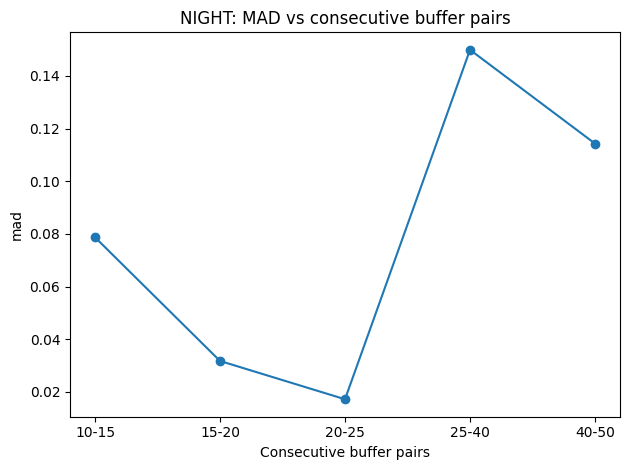

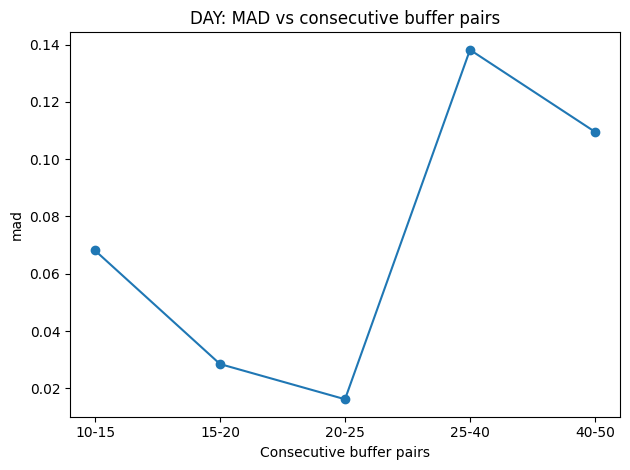

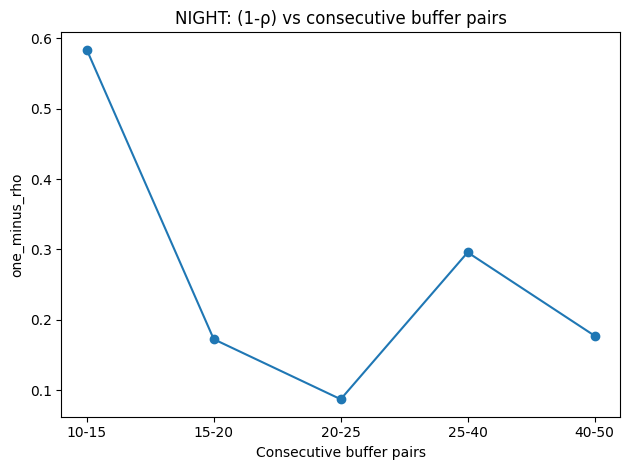

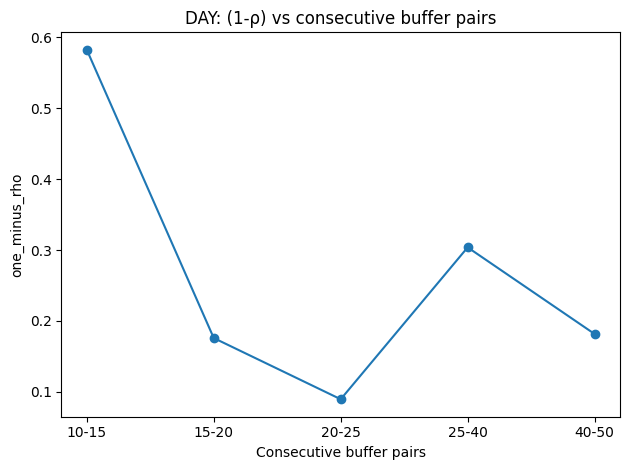


Support-commensurability (buffer ÷ mean segment length):
   buffer_m  ratio_buffer_to_mean_segment
0        10                      0.357143
1        15                      0.535714
2        20                      0.714286
3        25                      0.892857
4        40                      1.428571
5        50                      1.785714

--- Guidance for Buffer Selection ---
To select the best buffer size without bias, analyze the output above:

1. **Review the `Consecutive stability` tables.**
   - Look for the point where the `spearman_rho` is highest and `mad` is lowest.

2. **Examine the `MAD` and `(1-ρ)` plots.**
   - Find the 'elbow' or 'plateau' where the line flattens out.
   - The ideal buffer size is the second value in the buffer pair at the start of this plateau (e.g., if the plateau starts at the 20-25 pair, then 25m is a good choice).

3. **Consult the `Support-commensurability` table.**
   - Check if the chosen buffer size is well-proportioned to the mean se

In [2]:
# --- CONFIG ---
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from pathlib import Path

# --- README ---
# This code is a revision of the original biased analysis. The goal is to
# provide an unbiased way to select a buffer size.
#
# The primary method is to find the "elbow" or "plateau" in the stability metrics
# (MAD and 1-rho) calculated for consecutive buffer pairs. This approach
# avoids comparing all buffers to a single, pre-selected target (e.g., 25m),
# which creates a self-fulfilling prophecy.
#
# The "best" buffer size will be the smallest one at which the stability metrics
# (MAD and 1-rho) show a significant drop and subsequent plateau, indicating
# that further increases in buffer size do not lead to meaningful gains in
# stability. The Support-Commensurability Test provides an additional,
# independent metric to inform the final choice.
#
# To interpret the results:
# 1. Examine the `consecutive stability` tables for both day and night.
# 2. Look at the `MAD` and `(1-rho)` plots to identify the "elbow" point. This
#    is typically the buffer pair where the plot flattens out. The best buffer
#    size will be the second number in that pair (e.g., if the elbow is at 20-25,
#    then 25m is a good candidate).
# 3. Use the `Support-commensurability` table as a final check to ensure the
#    chosen buffer size is appropriate relative to your mean segment length.

pdir = Path("data/scores/edges_with_safety_score_point_buffer_")
buffers = [10, 15, 20, 25, 40, 50]  # Add or remove buffers as needed
day_col = "buffer_blended_day"
night_col = "buffer_blended_night"
mean_seg_len_m = 28 # Your mean segment length

# --- LOADING & ALIGNMENT ---
def load_buffer(b):
    """
    Loads and renames a single buffer score file.
    """
    df = pd.read_csv(pdir.with_name(f"{pdir.name}{b}m.csv"))
    # Expect a column 'edge_id' and the two score cols
    df = df.set_index("edge_id")[[night_col, day_col]].rename(
        columns={
            night_col: f"night_{b}",
            day_col: f"day_{b}"
        }
    )
    return df

# Load all buffers and inner-join on edge_id to keep common edges only
dfs = [load_buffer(b) for b in buffers]
master = pd.concat(dfs, axis=1, join="inner").sort_index()

# --- HELPERS ---
def pairwise_stats(values_by_buffer):
    """
    Calculates stability metrics for consecutive buffer pairs.
    values_by_buffer: dict[int, pd.Series] keyed by buffer (e.g., 10->series, 15->series, ...)
    Returns DataFrame with consecutive (b1,b2) stats.
    """
    rows = []
    ordered = sorted(values_by_buffer.keys())
    for i in range(len(ordered) - 1):
        b1, b2 = ordered[i], ordered[i+1]
        s1, s2 = values_by_buffer[b1].align(values_by_buffer[b2], join="inner")
        rho, _ = spearmanr(s1, s2)
        mad = (s1 - s2).abs().mean()
        rows.append({"b1": b1, "b2": b2, "spearman_rho": rho, "mad": mad})
    return pd.DataFrame(rows)

def plot_elbow(df_pairwise, metric, title, outfile=None):
    """
    Generates an elbow plot for a given stability metric.
    df_pairwise: output of pairwise_stats
    metric: 'mad' or 'spearman_rho' (for elbow you’ll likely use 'mad' or 1-rho)
    """
    x_labels = [f"{r.b1}-{r.b2}" for r in df_pairwise.itertuples()]
    y_vals = df_pairwise[metric].to_list()
    plt.figure()
    plt.plot(x_labels, y_vals, marker="o")
    plt.xlabel("Consecutive buffer pairs")
    plt.ylabel(metric)
    plt.title(title)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=150)
    plt.show()

# --- BUILD SERIES DICTS ---
# Night series by buffer
night_series = {b: master[f"night_{b}"] for b in buffers}
# Day series by buffer
day_series = {b: master[f"day_{b}"] for b in buffers}

# --- (1) STABILITY (RANK) TEST: consecutive pairs ---
night_pairwise = pairwise_stats(night_series)
day_pairwise = pairwise_stats(day_series)

print("\nConsecutive stability (NIGHT):")
print(night_pairwise)
print("\nConsecutive stability (DAY):")
print(day_pairwise)

# --- (2) ELBOW/PLATEAU TEST ---
# Use MAD elbow and 1-rho elbow
night_pairwise["one_minus_rho"] = 1 - night_pairwise["spearman_rho"]
day_pairwise["one_minus_rho"] = 1 - day_pairwise["spearman_rho"]

# Plots (one metric per plot; duplicate for night/day)
plot_elbow(night_pairwise, "mad", "NIGHT: MAD vs consecutive buffer pairs", outfile="night_mad_elbow.png")
plot_elbow(day_pairwise, "mad", "DAY: MAD vs consecutive buffer pairs", outfile="day_mad_elbow.png")
plot_elbow(night_pairwise, "one_minus_rho", "NIGHT: (1-ρ) vs consecutive buffer pairs", outfile="night_1minusrho_elbow.png")
plot_elbow(day_pairwise, "one_minus_rho", "DAY: (1-ρ) vs consecutive buffer pairs", outfile="day_1minusrho_elbow.png")

# --- (Optional) Save tables for appendix ---
night_pairwise.to_csv("consecutive_stability_night.csv", index=False)
day_pairwise.to_csv("consecutive_stability_day.csv", index=False)

# --- (3) SUPPORT-COMMENSURABILITY TEST ---
ratios = pd.DataFrame({
    "buffer_m": buffers,
    "ratio_buffer_to_mean_segment": [b / mean_seg_len_m for b in buffers]
})
print("\nSupport-commensurability (buffer ÷ mean segment length):")
print(ratios)
ratios.to_csv("support_commensurability.csv", index=False)

# --- Guidance for Interpretation ---
print("\n--- Guidance for Buffer Selection ---")
print("To select the best buffer size without bias, analyze the output above:")
print("\n1. **Review the `Consecutive stability` tables.**")
print("   - Look for the point where the `spearman_rho` is highest and `mad` is lowest.")
print("\n2. **Examine the `MAD` and `(1-ρ)` plots.**")
print("   - Find the 'elbow' or 'plateau' where the line flattens out.")
print("   - The ideal buffer size is the second value in the buffer pair at the start of this plateau (e.g., if the plateau starts at the 20-25 pair, then 25m is a good choice).")
print("\n3. **Consult the `Support-commensurability` table.**")
print("   - Check if the chosen buffer size is well-proportioned to the mean segment length. A ratio close to 1.0 is often a good sign of commensurability.")

Visualizing clusters in a 2D PCA plot (with n_clusters=3).


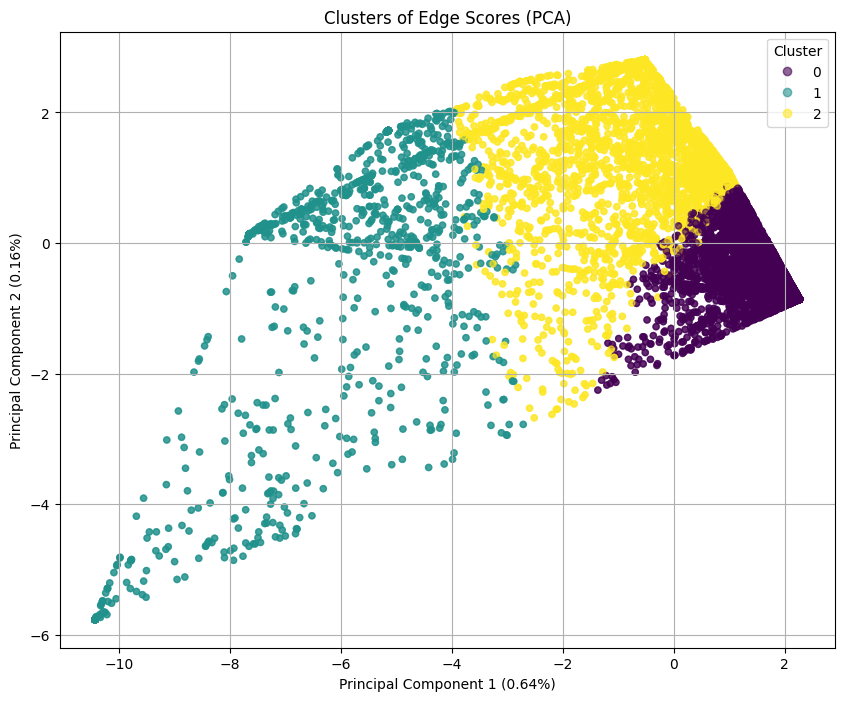


--- Mean Scores by Cluster for each Buffer Size ---
The buffer with the largest difference between cluster means is the best.
          day_mean_separation  night_mean_separation
buffer_m                                            
10                   0.187088               0.193276
15                   0.552683               0.594776
20                   0.670336               0.715245
25                   0.680014               0.724878
40                   0.720237               0.748035
50                   0.698913               0.704782

--- Conclusion from Clustering Analysis ---
Best buffer for DAY based on cluster separation: 40m (Separation: 0.7202)
Best buffer for NIGHT based on cluster separation: 40m (Separation: 0.7480)


In [3]:
# --- CONFIG ---
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# This script implements the Clustering Method to select a buffer size.
# It uses PCA to visualize how the buffers separate the data, then uses K-Means
# to find natural clusters and identifies the buffer size that best separates them.

# --- USER CONFIGURATION ---
pdir = Path("data/scores/edges_with_safety_score_point_buffer_")
buffers = [10, 15, 20, 25, 40, 50]  # The buffer sizes you are evaluating
day_col = "buffer_blended_day"
night_col = "buffer_blended_night"
n_clusters = 3 # Choose a reasonable number of clusters (e.g., low, medium, high risk).
seed = 42 # For reproducible results

# --- LOADING & PREPROCESSING ---
def load_buffer(b):
    """Loads and renames a single buffer score file."""
    df = pd.read_csv(pdir.with_name(f"{pdir.name}{b}m.csv"))
    df = df.set_index("edge_id")[[night_col, day_col]].rename(
        columns={night_col: f"night_{b}", day_col: f"day_{b}"}
    )
    return df

# Load all buffers and inner-join on edge_id
dfs = [load_buffer(b) for b in buffers]
master = pd.concat(dfs, axis=1, join="inner").sort_index()

# Combine day and night scores into a single dataset for clustering
day_scores = master[[f"day_{b}" for b in buffers]]
night_scores = master[[f"night_{b}" for b in buffers]]
scores = pd.concat([day_scores, night_scores], axis=1)

# Scale the scores to have a mean of 0 and a variance of 1. This is a crucial step
# for PCA and K-Means to ensure all buffer sizes contribute equally to the analysis.
scaler = StandardScaler()
scaled_scores = scaler.fit_transform(scores)

# --- DIMENSIONALITY REDUCTION & CLUSTERING ---
# Apply PCA to reduce the dimensionality for visualization.
pca = PCA(n_components=2, random_state=seed)
pca_components = pca.fit_transform(scaled_scores)
master['pca1'] = pca_components[:, 0]
master['pca2'] = pca_components[:, 1]

# Apply K-Means clustering to the scaled data.
kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init='auto')
master['cluster'] = kmeans.fit_predict(scaled_scores)

# --- VISUALIZATION OF CLUSTERS ---
print(f"Visualizing clusters in a 2D PCA plot (with n_clusters={n_clusters}).")
plt.figure(figsize=(10, 8))
scatter = plt.scatter(master['pca1'], master['pca2'], c=master['cluster'], cmap='viridis', s=20, alpha=0.6)
plt.title('Clusters of Edge Scores (PCA)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2f}%)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(True)
plt.show()

# --- ANALYZING CLUSTER SEPARATION ---
print("\n--- Mean Scores by Cluster for each Buffer Size ---")
print("The buffer with the largest difference between cluster means is the best.")

results = []
for b in buffers:
    day_means = master.groupby('cluster')[f'day_{b}'].mean()
    night_means = master.groupby('cluster')[f'night_{b}'].mean()
    
    # Calculate the separation as the difference between the max and min cluster means
    day_separation = day_means.max() - day_means.min()
    night_separation = night_means.max() - night_means.min()

    results.append({
        'buffer_m': b,
        'day_mean_separation': day_separation,
        'night_mean_separation': night_separation
    })

separation_df = pd.DataFrame(results).set_index('buffer_m')
print(separation_df)

# --- SUMMARIZE FINDINGS ---
best_day_buffer = separation_df['day_mean_separation'].idxmax()
best_night_buffer = separation_df['night_mean_separation'].idxmax()

print("\n--- Conclusion from Clustering Analysis ---")
print(f"Best buffer for DAY based on cluster separation: {best_day_buffer}m (Separation: {separation_df.loc[best_day_buffer, 'day_mean_separation']:.4f})")
print(f"Best buffer for NIGHT based on cluster separation: {best_night_buffer}m (Separation: {separation_df.loc[best_night_buffer, 'night_mean_separation']:.4f})")

!!! Using SIMULATED ground truth. Please replace with your actual data. !!!
Simulated Ground Truth Class Distribution:
ground_truth
1    15199
0     3773
Name: count, dtype: int64

--- Generating ROC Curves ---


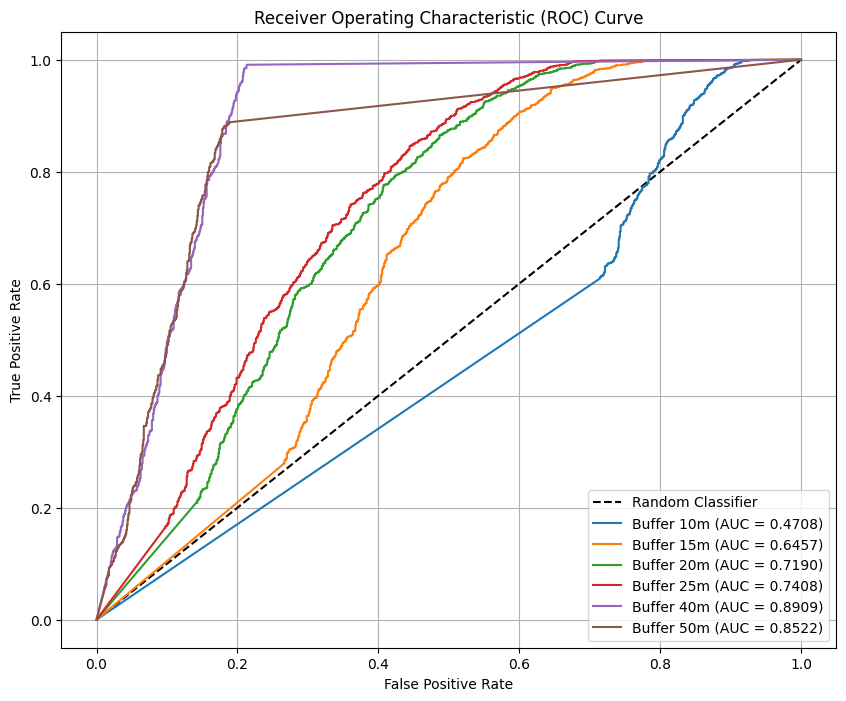


--- Final Results (Sorted by Performance) ---
The buffer size with the highest AUC-ROC score is the best at distinguishing between your classes.
   buffer_m  auc_roc_score
4        40       0.890928
5        50       0.852245
3        25       0.740811
2        20       0.719029
1        15       0.645659
0        10       0.470791

Conclusion: The best buffer size based on sensitivity-specificity is 40.0m with an AUC-ROC of 0.8909.


In [4]:
# --- CONFIG ---
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# This script implements the Sensitivity-Specificity Method.
# It evaluates each buffer size's score as a potential classifier by plotting
# its ROC curve and calculating the AUC-ROC score.

# !!! IMPORTANT: REPLACE THE SIMULATED GROUND-TRUTH DATA WITH YOUR OWN LABELS !!!

pdir = Path("data/scores/edges_with_safety_score_point_buffer_")
buffers = [10, 15, 20, 25, 40, 50]  # The buffer sizes you are evaluating
day_col = "buffer_blended_day"
night_col = "buffer_blended_night"
seed = 42 # For reproducible results

# --- LOADING & ALIGNMENT ---
def load_buffer(b):
    """
    Loads and renames a single buffer score file.
    """
    df = pd.read_csv(pdir.with_name(f"{pdir.name}{b}m.csv"))
    df = df.set_index("edge_id")[[night_col, day_col]].rename(
        columns={
            night_col: f"night_{b}",
            day_col: f"day_{b}"
        }
    )
    return df

# Load all buffers and inner-join on edge_id to keep common edges only
dfs = [load_buffer(b) for b in buffers]
master = pd.concat(dfs, axis=1, join="inner").sort_index()

# --- SIMULATED GROUND TRUTH ---
# !!! You MUST replace this section with your actual ground-truth data. !!!
# This simulation creates a binary 'y' label (e.g., 1 for high-risk, 0 for low-risk)
# for demonstration purposes. A real-world example would be a column
# with '1' for edges with historical accidents and '0' for those without.
print("!!! Using SIMULATED ground truth. Please replace with your actual data. !!!")
np.random.seed(seed)
master['ground_truth'] = 0
high_risk_edges = master[master[f'day_{buffers[-2]}'] > 0.1].index
master.loc[high_risk_edges, 'ground_truth'] = 1
master.loc[master.sample(frac=0.1, random_state=seed).index, 'ground_truth'] = np.random.randint(0, 2, size=int(len(master) * 0.1))

y_true = master['ground_truth']
print(f"Simulated Ground Truth Class Distribution:\n{y_true.value_counts()}")

# --- SENSITIVITY-SPECIFICITY ANALYSIS ---
# We will use the 'day' scores for this example.
scores_by_buffer = {b: master[f'day_{b}'] for b in buffers}
results = []
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

print("\n--- Generating ROC Curves ---")
for b, X_scores in scores_by_buffer.items():
    # Split data to prevent overfitting to the ground truth
    X_train, X_test, y_train, y_test = train_test_split(
        X_scores, y_true, test_size=0.3, random_state=seed, stratify=y_true
    )
    
    # Since we are not training a model, we use the raw scores from the test set
    # as the classifier's "probabilities". A higher score should indicate a
    # higher likelihood of being the positive class (1).
    fpr, tpr, thresholds = roc_curve(y_test, X_test)
    auc_score = roc_auc_score(y_test, X_test)
    
    # Plot the ROC curve for the current buffer size
    plt.plot(fpr, tpr, label=f'Buffer {b}m (AUC = {auc_score:.4f})')
    results.append({'buffer_m': b, 'auc_roc_score': auc_score})

# --- VISUALIZATION ---
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- SUMMARIZE RESULTS ---
results_df = pd.DataFrame(results).sort_values(by='auc_roc_score', ascending=False)

print("\n--- Final Results (Sorted by Performance) ---")
print("The buffer size with the highest AUC-ROC score is the best at distinguishing between your classes.")
print(results_df)

best_buffer = results_df.iloc[0]['buffer_m']
best_score = results_df.iloc[0]['auc_roc_score']
print(f"\nConclusion: The best buffer size based on sensitivity-specificity is {best_buffer}m with an AUC-ROC of {best_score:.4f}.")